In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, add_dummy_feature
from sklearn.linear_model import LinearRegression

In [2]:
rng = np.random.default_rng(seed= 42)
m = 200 # number of instances
X = 6 * rng.random((m,1)) -3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m,1))

In [3]:
poly_features = PolynomialFeatures(degree= 2, include_bias= False)
x_poly = poly_features.fit_transform(X)
x_poly_b = add_dummy_feature(x_poly)

print(X[0])
print(x_poly_b[0])

[1.64373629]
[1.         1.64373629 2.701869  ]


In [4]:
lin_reg = LinearRegression(fit_intercept= False)
lin_reg.fit(x_poly_b, y)
print("Score : ", lin_reg.score(x_poly_b, y))

print(lin_reg.intercept_)
print(lin_reg.coef_)

y_pred = lin_reg.predict(x_poly_b)

Score :  0.8320899772267598
0.0
[[2.00540719 1.11022126 0.50526985]]


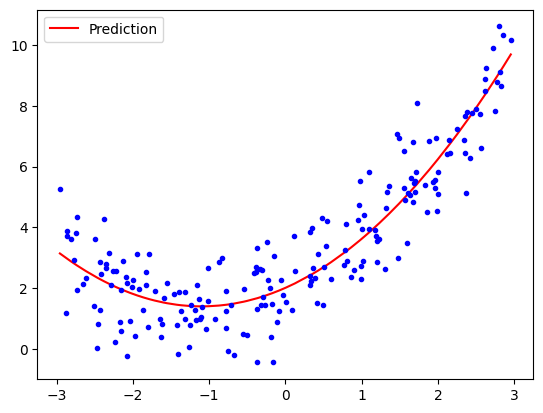

In [5]:
sort_idx = X[:, 0].argsort()
X_sorted = X[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.plot(X_sorted, y_pred_sorted, 'r-', label= 'Prediction')
plt.plot(X, y, 'b.')
plt.legend()
plt.show()

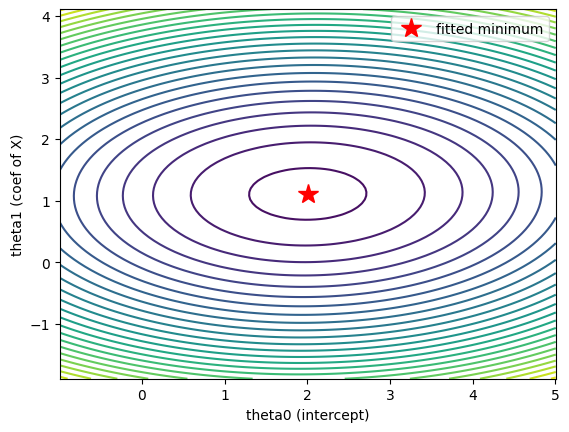

In [ ]:
theta0_range = np.linspace(lin_reg.coef_[0][0] - 3, lin_reg.coef_[0][0] + 3, 100)
theta1_range = np.linspace(lin_reg.coef_[0][1] - 3, lin_reg.coef_[0][1] + 3, 100)

T0, T1 = np.meshgrid(theta0_range, theta1_range)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        teta_ij = np.array([[T0[i,j]], [T1[i,j]]]) 
        teta_ij = np.append(teta_ij, [[lin_reg.coef_[0][2]]], axis=0) 
        preds = x_poly_b @ teta_ij
        cost[i, j] = np.mean((preds - y) ** 2)

plt.contour(T0, T1, cost, levels=30, cmap='viridis')
plt.plot(lin_reg.coef_[0][0], lin_reg.coef_[0][1], 'r*', markersize=15, label='fitted minimum')
plt.xlabel('theta0 (intercept)')
plt.ylabel('theta1 (coef of X)')
plt.legend()
plt.show()
